In [ ]:
#Part A: Understanding the Dataset

#Q1. Dataset Overview
import pandas as pd
df=pd.read_csv("/content/agriculture_yield_dataset.csv")
row,col=df.shape
print("Number of rows:",row)
print("Number of columns:",col)

print("Names of columns: ",df.columns.to_list)

print("First 10 rows of the dataset:")
print(df.head(10))

Number of rows: 1500
Number of columns: 8
Names of columns:  <bound method IndexOpsMixin.tolist of Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')>
First 10 rows of the dataset:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36

In [ ]:
#Q2. Data Types and Missing Values
print("Data types of each column:")
display(df.dtypes)

missing_values = df.isnull().sum()
missing_values_exist = missing_values[missing_values > 0]

if not missing_values_exist.empty:
    print("\nMissing values are present in the following columns:")
    display(missing_values_exist)
else:
    print("\nNo missing values found in the dataset.")

Data types of each column:


,0
rainfall_mm,float64
temperature_c,float64
fertilizer_kg,float64
irrigation_hours,float64
soil_ph,float64
crop_type,object
soil_type,object
yield_ton_per_hectare,float64



No missing values found in the dataset.


In [ ]:
#Q3
summary=df.describe()
print(summary)

highest_mean_feature=summary.loc['mean'].idxmax()
print("Feature with the highest mean:",highest_mean_feature)

highest_std_feature=summary.loc['std'].idxmax()
print("Feature with the highest std:",highest_std_feature)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis

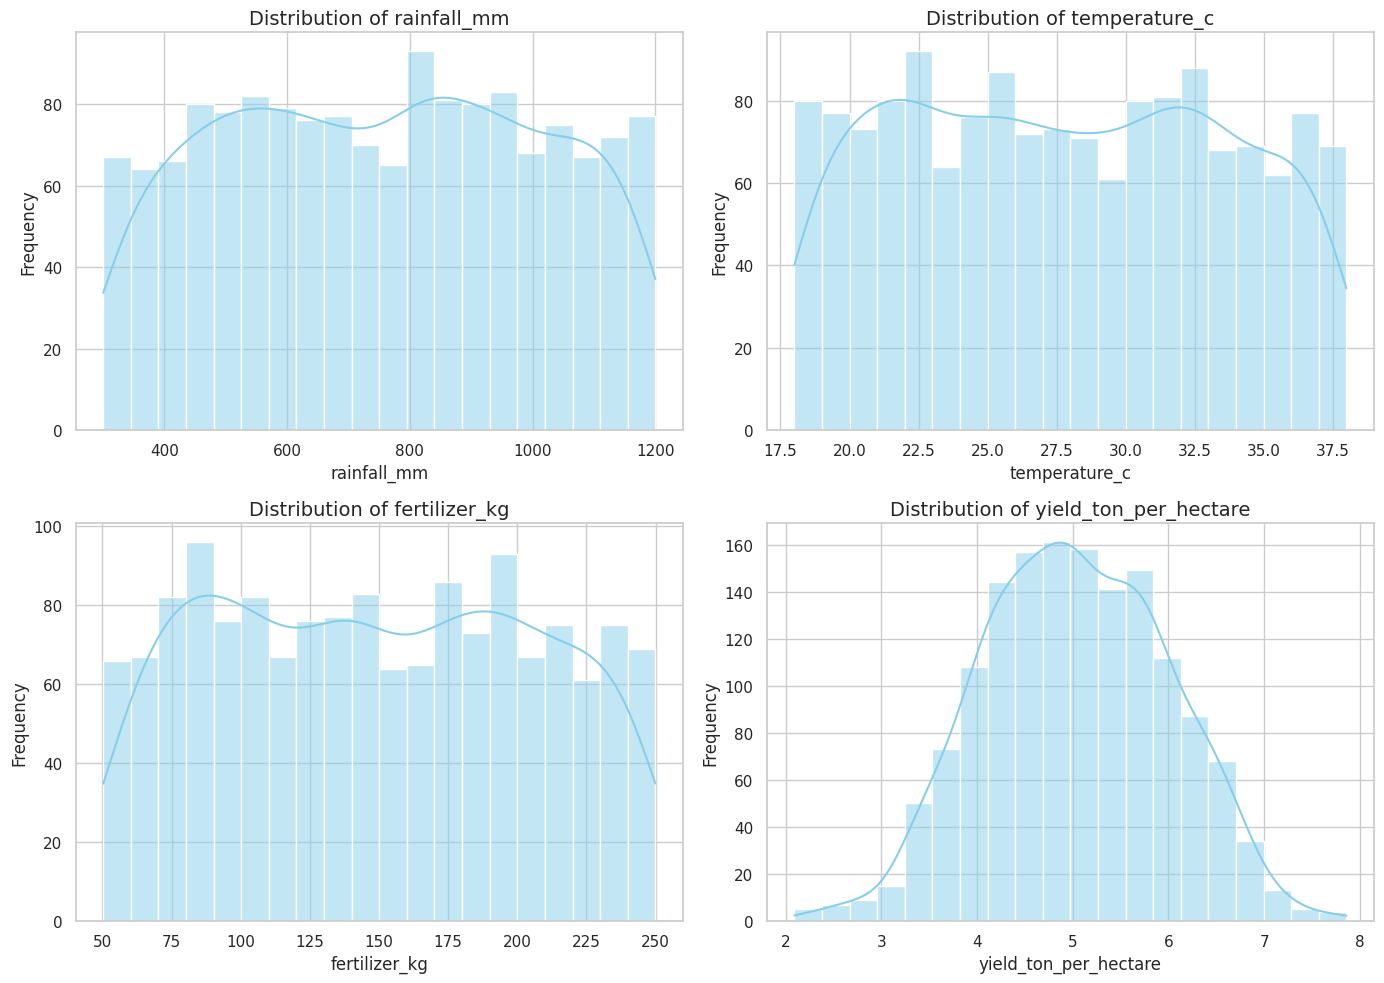

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
sns.set_theme(style="whitegrid")

# Define the columns we want to plot
features = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

# Create a 2x2 grid of subplots
plt.figure(figsize=(14, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    # Plot histogram with a Kernel Density Estimate (KDE) curve
    sns.histplot(df[feature].dropna(), kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Observations for Rainfall (mm) Histogram:
- **Observation 1:** The distribution appears somewhat left-skewed, indicating that higher rainfall values are less frequent than moderate ones.
- **Observation 2:** There's a wide range of rainfall, from approximately 300 mm to 1200 mm, suggesting diverse climatic conditions in the dataset.
- **Observation 3:** The peak frequency seems to be around 700-800 mm, with a noticeable drop-off towards the extremes.

#### Observations for Temperature (°C) Histogram:
- **Observation 1:** The temperature distribution appears relatively uniform or slightly multi-modal, without a strong central peak, suggesting a variety of temperature conditions are represented.
- **Observation 2:** Temperatures range from around 18°C to 38°C, covering a typical range for agricultural regions.
- **Observation 3:** There isn't a clear normal distribution, which might indicate different growing seasons or geographical locations within the dataset.

#### Observations for Fertilizer (kg) Histogram:
- **Observation 1:** The distribution of fertilizer usage seems quite uniform across its range, from approximately 50 kg to 250 kg, implying varied application rates.
- **Observation 2:** There are no obvious extreme outliers, suggesting that fertilizer amounts are consistently within a certain operational range.
- **Observation 3:** The lack of a single strong peak suggests that different crops or farming practices might employ different fertilizer strategies.

#### Observations for Yield (ton/hectare) Histogram:
- **Observation 1:** The yield distribution appears roughly symmetrical and somewhat bell-shaped, centered around a mean yield.
- **Observation 2:** Most yields fall between 4 and 6 tons per hectare, with fewer instances of very low or very high yields.
- **Observation 3:** This distribution suggests that while there's variability, a typical yield range is consistently observed.

### Q5. Crop Type Analysis

Number of records for each crop type:


,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


/tmp/ipykernel_4473/2936638175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='crop_type', order=crop_type_counts.index, palette='viridis')


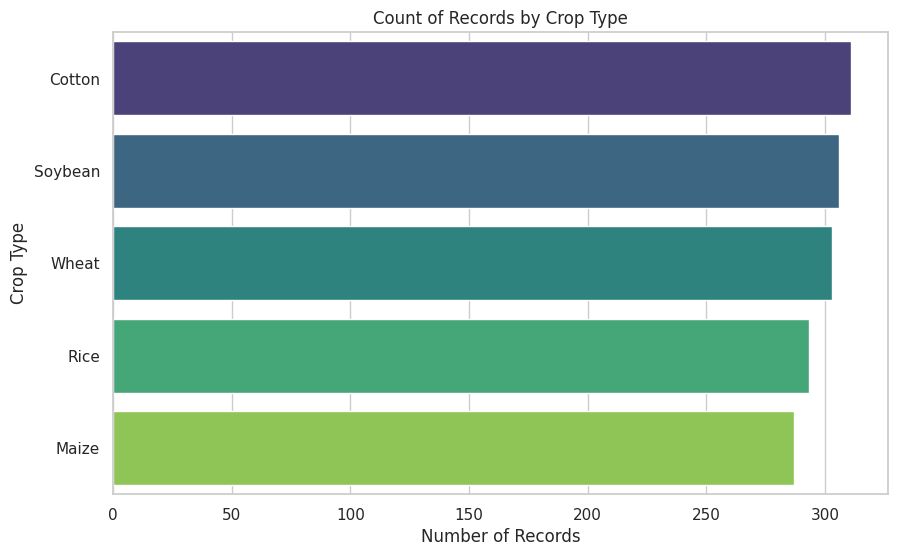


Most frequently appearing crop: Cotton


In [ ]:
# Find the number of records for each crop type
crop_type_counts = df['crop_type'].value_counts()
print("Number of records for each crop type:")
display(crop_type_counts)

# Create a count plot (bar chart) for crop_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='crop_type', order=crop_type_counts.index, palette='viridis')
plt.title('Count of Records by Crop Type')
plt.xlabel('Number of Records')
plt.ylabel('Crop Type')
plt.show()

# Which crop appears most frequently?
most_frequent_crop = crop_type_counts.index[0]
print(f"\nMost frequently appearing crop: {most_frequent_crop}")

### Q6. Soil Type Analysis

Frequency of each soil type:


,count
soil_type,
Clay,534
Sandy,492
Loamy,474


/tmp/ipykernel_4473/1687320915.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='soil_type', order=soil_type_counts.index, palette='plasma')


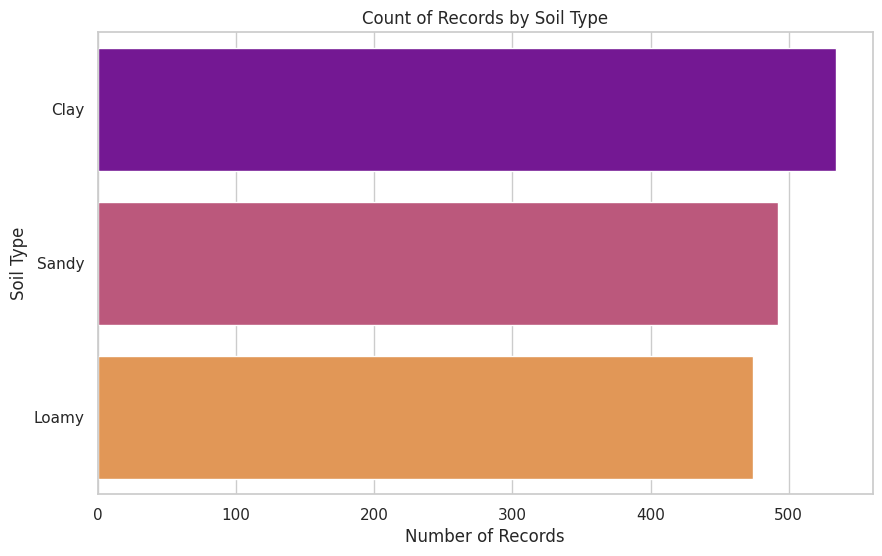


Most common soil type: Clay


In [ ]:
# Find the frequency of each soil type
soil_type_counts = df['soil_type'].value_counts()
print("Frequency of each soil type:")
display(soil_type_counts)

# Create a count plot for soil_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='soil_type', order=soil_type_counts.index, palette='plasma')
plt.title('Count of Records by Soil Type')
plt.xlabel('Number of Records')
plt.ylabel('Soil Type')
plt.show()

# Which soil type is most common?
most_common_soil_type = soil_type_counts.index[0]
print(f"\nMost common soil type: {most_common_soil_type}")

### Q7. Yield Distribution

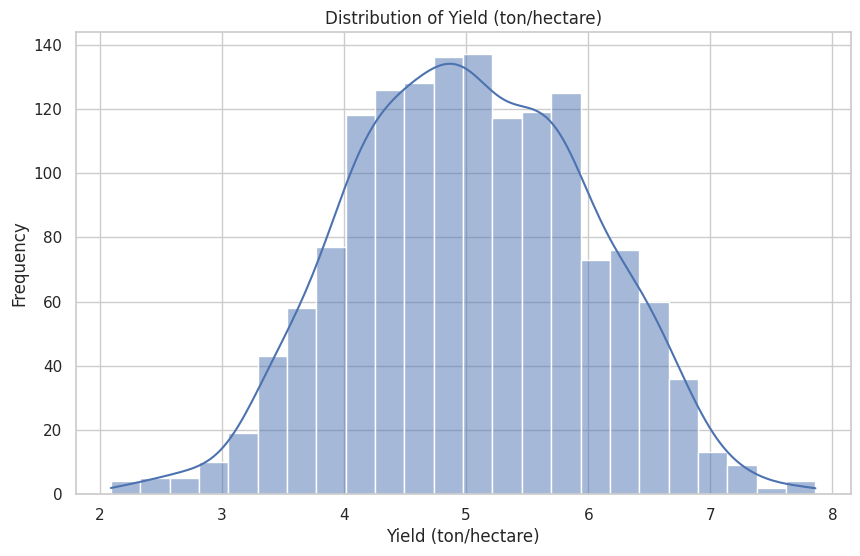

In [ ]:
# Create a histogram of yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

#### Observations for Yield Distribution:
- **Is the distribution approximately normal?** Based on the histogram, the distribution of `yield_ton_per_hectare` appears to be approximately normal (bell-shaped), with most values concentrated around the mean.
- **Are there any noticeable outliers?** Visually, there are no extreme values that stand significantly apart from the rest of the data, suggesting the absence of obvious outliers.

### Q8. Scatter Plot Analysis

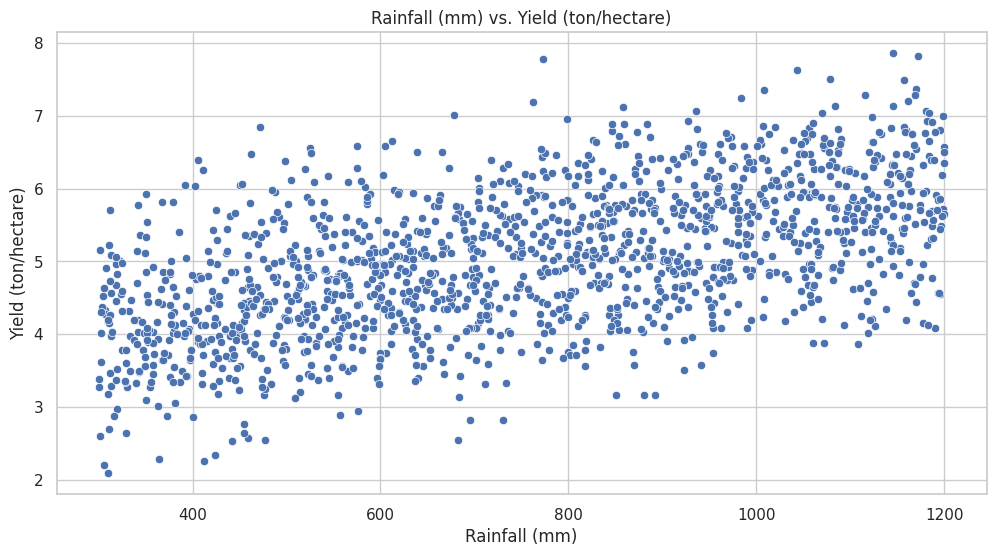

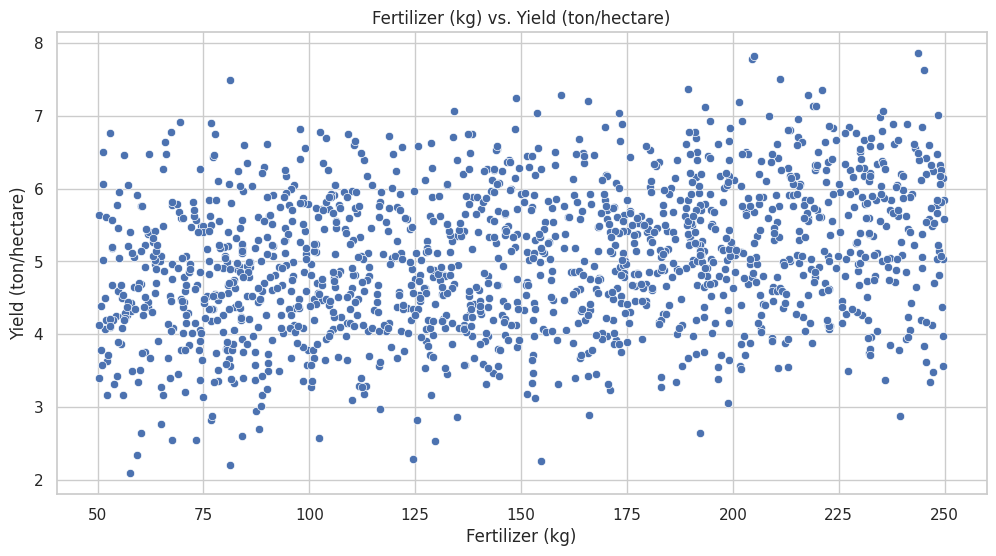

In [ ]:
# Scatter plot: rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(12, 6))
sns.scatterplot(x='rainfall_mm', y='yield_ton_per_hectare', data=df)
plt.title('Rainfall (mm) vs. Yield (ton/hectare)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton/hectare)')
plt.show()

# Scatter plot: fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(12, 6))
sns.scatterplot(x='fertilizer_kg', y='yield_ton_per_hectare', data=df)
plt.title('Fertilizer (kg) vs. Yield (ton/hectare)')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton/hectare)')
plt.show()

**Which feature appears to have a stronger relationship with yield?** fertilizer_kg might show a slightly more concentrated positive trend. However, a more definitive answer comes from the correlation analysis.

### Q9. Correlation Analysis

Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


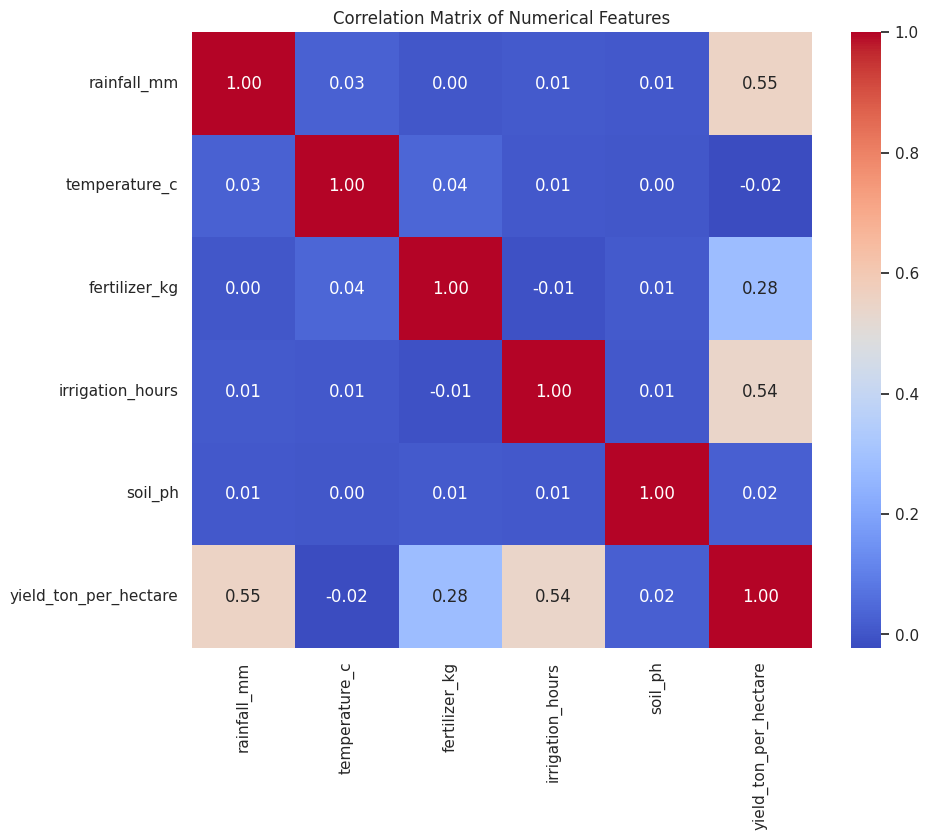


Top three features most correlated with crop yield (absolute value):


,yield_ton_per_hectare
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043


In [ ]:
# Generate a correlation matrix for numerical features
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()
print("Correlation Matrix:")
display(correlation_matrix)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify the top three features most correlated with crop yield
yield_correlations = correlation_matrix['yield_ton_per_hectare'].abs().sort_values(ascending=False)
# Exclude 'yield_ton_per_hectare' itself
top_correlated_features = yield_correlations[1:4]
print("\nTop three features most correlated with crop yield (absolute value):")
display(top_correlated_features)

### Q10. Group-Based Analysis

In [ ]:
# Calculate the average yield for each crop type
average_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average Yield by Crop Type:")
display(average_yield_by_crop)

# Calculate the average yield for each soil type
average_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("\nAverage Yield by Soil Type:")
display(average_yield_by_soil)

# Which crop type has the highest average yield?
highest_yield_crop = average_yield_by_crop.index[0]
highest_yield_crop_value = average_yield_by_crop.iloc[0]
print(f"\nCrop type with the highest average yield: {highest_yield_crop} ({highest_yield_crop_value:.2f} tons/hectare)")

# Which soil type has the highest average yield?
highest_yield_soil = average_yield_by_soil.index[0]
highest_yield_soil_value = average_yield_by_soil.iloc[0]
print(f"Soil type with the highest average yield: {highest_yield_soil} ({highest_yield_soil_value:.2f} tons/hectare)")

Average Yield by Crop Type:


,yield_ton_per_hectare
crop_type,
Rice,5.494744
Soybean,5.173431
Wheat,4.989472
Maize,4.897143
Cotton,4.607299



Average Yield by Soil Type:


,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882



Crop type with the highest average yield: Rice (5.49 tons/hectare)
Soil type with the highest average yield: Loamy (5.37 tons/hectare)


## Part C: Data Preparation

### Q11. Feature Encoding

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(categorical_cols)}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False) # drop_first=False to keep all categories

print("\nFirst five rows of the transformed dataset (after One-Hot Encoding):")
display(df_encoded.head())

Categorical columns identified: ['crop_type', 'soil_type']

First five rows of the transformed dataset (after One-Hot Encoding):


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


### Q12. Feature Selection

In [ ]:
# Define target variable (y)
y = df_encoded['yield_ton_per_hectare']

# Define input features (X) - dropping the target variable
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

print("Target variable (y) is: 'yield_ton_per_hectare'")
print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")

Target variable (y) is: 'yield_ton_per_hectare'
Shape of input features (X): (1500, 13)
Shape of target variable (y): (1500,)


## Part D: Machine Learning

### Q13. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


### Q14. Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the model coefficients and intercept
print("Model Intercept:", model.intercept_)

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))

# Which feature has the highest positive coefficient?
highest_positive_coefficient_feature = coefficients[coefficients['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).iloc[0]
print(f"\nFeature with the highest positive coefficient: {highest_positive_coefficient_feature['Feature']} (Coefficient: {highest_positive_coefficient_feature['Coefficient']:.2f})")

Model Intercept: 1.9111026182800726

Model Coefficients:


,Feature,Coefficient
7,crop_type_Rice,0.477369
11,soil_type_Loamy,0.365627
3,irrigation_hours,0.198327
8,crop_type_Soybean,0.095096
10,soil_type_Clay,0.062653
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149



Feature with the highest positive coefficient: crop_type_Rice (Coefficient: 0.48)
